# Day 19: GPU Architecture: SMs, Memory Hierarchy, HBM
> *100 Days of Inference* | Layer: **Infrastructure** | Book: *Inference Engineering* Ch 3.1

**Prerequisite:** Day 18

## What problem does this solve?

All the inference optimizations so far (kernel fusion, tensor parallelism, FlashAttention) reference GPU hardware concepts without explaining them. Understanding the actual hardware — streaming multiprocessors, memory hierarchy, HBM — gives the mental model to reason about why these optimizations work and when to apply them.

## Concept Overview

GPUs are purpose-built for parallelism. Where a CPU has 16-96 powerful cores, a GPU has 1000s of simpler cores organized into **Streaming Multiprocessors (SMs)**.

**H100 SXM specs:**
- 132 Streaming Multiprocessors (SMs)
- 16,896 FP32 CUDA cores (128 per SM)
- 528 Tensor Core units (FP16/BF16/FP8)
- 80 GB HBM3 at 3.35 TB/s
- 50 MB L2 cache

**For inference:** Tensor Cores are the critical resource — they do matrix multiplications in hardware (GEMM), which is what every linear layer in a transformer uses. One Tensor Core operation computes a 16×16 matrix multiply in 1 clock cycle.

In [1]:
!pip install -q numpy matplotlib torch 2>/dev/null
import numpy as np
import matplotlib.pyplot as plt
import torch
import time
print(f"PyTorch: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"GPU Memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")

PyTorch: 2.11.0+cu130
CUDA available: True
GPU: NVIDIA GB10
GPU Memory: 128.5 GB


## Part 1: Streaming Multiprocessors (SMs) — The GPU's CPU Cores

A GPU is made of many **Streaming Multiprocessors (SMs)**. Each SM is like a small CPU cluster:
- Thousands of CUDA cores (basic floating-point units)
- Tensor Cores (specialized matrix multiply hardware)
- Shared memory (small, fast, programmer-managed cache: ~192KB per SM on H100)
- L1/L2 cache

An H100 SXM has **132 SMs**. All SMs run in parallel. A CUDA kernel launches one thread per element — the runtime maps threads to SMs automatically.

**Infrastructure analogy:** An SM is like a single server node. The GPU is the data center. Threads are requests. The GPU scheduler maps threads to SMs like a load balancer.

In [2]:
# Model GPU compute capacity
gpu_specs = {
    "A100 SXM": {"sms": 108, "cuda_cores_per_sm": 64, "tensor_cores_per_sm": 4,
                 "fp16_tflops": 312, "hbm_bandwidth_tbs": 2.0, "hbm_capacity_gb": 80},
    "H100 SXM": {"sms": 132, "cuda_cores_per_sm": 128, "tensor_cores_per_sm": 4,
                 "fp16_tflops": 989, "hbm_bandwidth_tbs": 3.35, "hbm_capacity_gb": 80},
    "B200":     {"sms": 160, "cuda_cores_per_sm": 128, "tensor_cores_per_sm": 4,
                 "fp8_tflops": 4500, "fp16_tflops": 2250, "hbm_bandwidth_tbs": 8.0, "hbm_capacity_gb": 192},
    "DGX Spark (GB10)": {"sms": 128, "cuda_cores_per_sm": 128, "tensor_cores_per_sm": 4,
                          "fp16_tflops": 1000, "hbm_bandwidth_tbs": 4.0, "hbm_capacity_gb": 128},
}

print(f"{'GPU':<22} {'SMs':>5} {'CUDA cores':>11} {'FP16 TFLOPS':>13} {'HBM BW':>9} {'HBM GB':>8} {'Ops:Byte':>9}")
print("-" * 85)
for name, s in gpu_specs.items():
    total_cuda = s.get("sms", 0) * s.get("cuda_cores_per_sm", 0)
    fp16 = s.get("fp16_tflops", s.get("fp8_tflops", 0) / 2)
    bw = s.get("hbm_bandwidth_tbs", 0)
    ops_byte = fp16 * 1e12 / (bw * 1e12) if bw > 0 else 0
    print(f"{name:<22} {s.get('sms',0):>5} {total_cuda:>11,} {fp16:>13.0f} {bw:>8.2f}T {s.get('hbm_capacity_gb',0):>8} {ops_byte:>9.0f}")

print()
print("Key: The ops:byte ratio determines what workloads are compute vs memory bound.")
print("Higher ops:byte = compute ceiling harder to hit; lower = memory bound more likely.")

GPU                      SMs  CUDA cores   FP16 TFLOPS    HBM BW   HBM GB  Ops:Byte
-------------------------------------------------------------------------------------
A100 SXM                 108       6,912           312     2.00T       80       156
H100 SXM                 132      16,896           989     3.35T       80       295
B200                     160      20,480          2250     8.00T      192       281
DGX Spark (GB10)         128      16,384          1000     4.00T      128       250

Key: The ops:byte ratio determines what workloads are compute vs memory bound.
Higher ops:byte = compute ceiling harder to hit; lower = memory bound more likely.


## Part 2: GPU Memory Hierarchy

The GPU has a deep memory hierarchy:

```
Registers (KB/SM) ← fastest, per-thread
Shared Memory (192KB/SM) ← fast, programmable L1
L2 Cache (50MB H100) ← shared across SMs
HBM (High Bandwidth Memory) ← slow(er), large capacity
```

For inference, **HBM is the bottleneck** — model weights live here and must be loaded for every layer.

FlashAttention exploits this hierarchy: it tiles the attention computation to maximize use of shared memory and L2, minimizing HBM round-trips.

**Infrastructure analogy:**
- Registers = CPU registers (sub-nanosecond)
- Shared memory = L1 cache (very fast, small)
- L2 = L2/L3 cache
- HBM = DRAM (fast for a GPU, but the bottleneck)

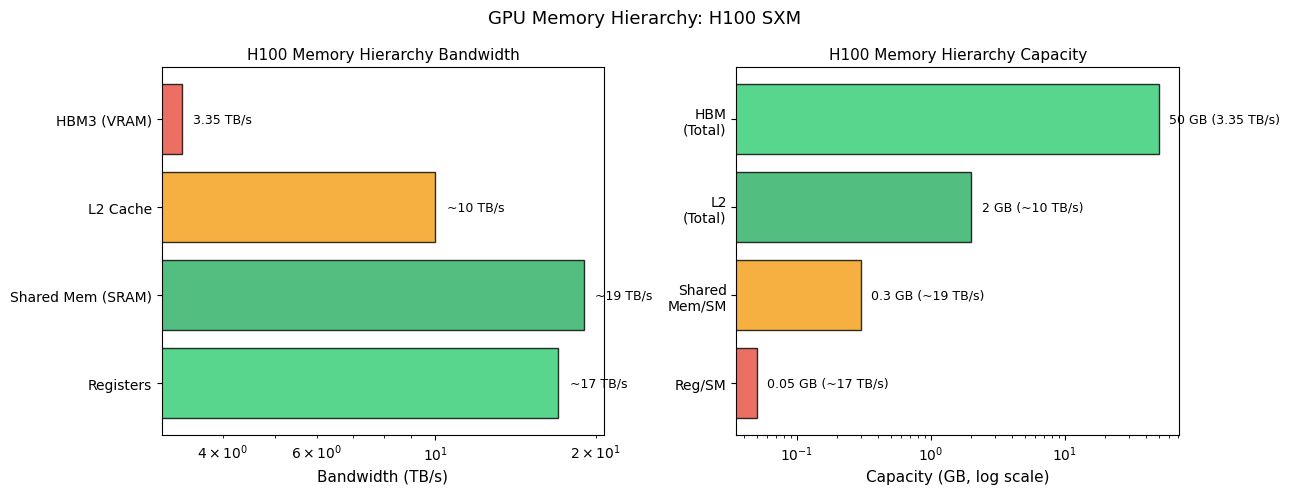

Inference implication:
  Model weights live in HBM (slow)
  FlashAttention tiles attention to fit in Shared Memory (fast)
  This is why FlashAttention 2-4x faster than naive attention at long sequences


In [3]:
# Visualize memory hierarchy bandwidth and latency
import matplotlib.pyplot as plt

hierarchy = [
    ("Registers",      "~17 TB/s", 0.3, "#2ecc71",   "1-2 cycles"),
    ("Shared Mem (SRAM)", "~19 TB/s", 0.5, "#27ae60", "~20 cycles"),
    ("L2 Cache",       "~10 TB/s", 0.8, "#f39c12",  "~100 cycles"),
    ("HBM3 (VRAM)",    "3.35 TB/s", 1.0, "#e74c3c",  "~300 cycles"),
]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

# Bandwidth comparison
names = [h[0] for h in hierarchy]
bws = [float(h[1].lstrip('~').split()[0]) for h in hierarchy]
colors = [h[3] for h in hierarchy]

ax1.barh(names, bws, color=colors, alpha=0.8, edgecolor='black')
ax1.set_xlabel("Bandwidth (TB/s)", fontsize=11)
ax1.set_title("H100 Memory Hierarchy Bandwidth", fontsize=11)
ax1.set_xscale("log")
for i, bw in enumerate(bws):
    ax1.text(bw * 1.05, i, f"{hierarchy[i][1]}", va='center', fontsize=9)

# Memory pyramid
pyramid_sizes = [0.05, 0.3, 2, 50]
pyramid_labels = ["Reg/SM", "Shared\nMem/SM", "L2\n(Total)", "HBM\n(Total)"]
pyramid_bws = ["~17 TB/s", "~19 TB/s", "~10 TB/s", "3.35 TB/s"]

ax2.barh(pyramid_labels, pyramid_sizes, color=colors[::-1], alpha=0.8, edgecolor='black', log=True)
ax2.set_xlabel("Capacity (GB, log scale)", fontsize=11)
ax2.set_title("H100 Memory Hierarchy Capacity", fontsize=11)
for i, (size, bw) in enumerate(zip(pyramid_sizes, pyramid_bws)):
    ax2.text(size * 1.2, i, f"{size} GB ({bw})", va='center', fontsize=9)

plt.suptitle("GPU Memory Hierarchy: H100 SXM", fontsize=13)
plt.tight_layout()
plt.show()

print("Inference implication:")
print("  Model weights live in HBM (slow)")
print("  FlashAttention tiles attention to fit in Shared Memory (fast)")
print("  This is why FlashAttention 2-4x faster than naive attention at long sequences")

## Try These Experiments

1. **SM occupancy:** An H100 SM can run up to 2048 threads concurrently. For a kernel launched on a 4096×4096 matrix multiply with block size 256, how many SMs are active? What is the occupancy (fraction of maximum threads)?

2. **HBM bandwidth calculation:** A 7B model at FP16 has 14 GB of weights. During decode, each token requires loading all weights once. At 3.35 TB/s HBM bandwidth, what is the minimum possible time per decode step? How does this compare to the Day 06 arithmetic intensity measurements?

3. **Shared memory as FlashAttention enabler:** H100 has 192KB of shared memory per SM. An attention block stores Q, K, V tiles. For attention head dimension d=128 at FP16, what is the maximum tile size (sequence length chunk) that fits in shared memory? This determines FlashAttention's blocking factor.

## Key Takeaways

- The H100's 132 SMs each contain 128 CUDA cores and 4 Tensor Core units — together they provide 989 TFLOPS of FP16 compute.
- The memory hierarchy has 1000x bandwidth difference between registers and HBM — exploiting the fast levels is why FlashAttention and kernel fusion matter.
- HBM is the bottleneck for memory-bound operations. Every optimization technique in inference is ultimately about reducing or hiding HBM access latency.
- Tensor Cores accelerate matrix multiplies specifically — all the GEMM operations in attention and FFN layers.
- **What's next:** Day 20 — GPU generations: Hopper, Ada, Blackwell, Rubin — what's different and why.

## References
- *Inference Engineering* Ch 3.1